# LSTM Model for Personal Health Mention Classification
**CSC4093/DSC4213: Neural Networks and Deep Learning (2024/25)**

Classifying tweets as personal health mentions (1) or non-personal health mentions (0) using LSTM.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Load datasets
train_data = pd.read_csv('phm_train.csv')
test_data = pd.read_csv('phm_test.csv')

print('Training set shape:', train_data.shape)
print('Test set shape:', test_data.shape)
print()
print(train_data.head())

Training set shape: (9991, 3)
Test set shape: (3331, 3)

       tweet_id  label                                              tweet
0  6.430000e+17      0  user_mention all i can tell you is i have had ...
1  6.440000e+17      0  my doctor told me stop he gave me sum pop i mi...
2  8.150000e+17      1  i take tylenol and i wake up in the middle of ...
3  6.820000e+17      0  i got xans in an advil bottle i dont take them...
4  6.440000e+17      1  mom says i need to stop eating so much bc ive ...


In [3]:
# Check label distribution
print('Training label distribution:')
print(train_data['label'].value_counts())
print()
print('Test label distribution:')
print(test_data['label'].value_counts())

Training label distribution:
label
0    7091
1    2900
Name: count, dtype: int64

Test label distribution:
label
0    2364
1     967
Name: count, dtype: int64


In [4]:
# Preprocessing
english_stops = set(stopwords.words('english'))

def preprocess_text(text_series):
    """Clean tweet text: remove non-alpha chars, stopwords, and lowercase."""
    x = text_series.copy()
    x = x.replace({'[^A-Za-z]': ' '}, regex=True)  # remove non-alphabetic characters
    x = x.apply(lambda tweet: [w for w in tweet.split() if w.lower() not in english_stops])  # remove stopwords
    x = x.apply(lambda tweet: [w.lower() for w in tweet])  # lowercase
    return x

x_train_raw = preprocess_text(train_data['tweet'])
y_train_full = train_data['label'].values

x_test_final = preprocess_text(test_data['tweet'])
y_test_final = test_data['label'].values

print('Preprocessed training sample:')
print(x_train_raw.head())

Preprocessed training sample:
0    [user, mention, tell, relapses, cure, hear, do...
1    [doctor, told, stop, gave, sum, pop, mix, w, a...
2    [take, tylenol, wake, middle, night, put, ice,...
3    [got, xans, advil, bottle, dont, take, shits, ...
4    [mom, says, need, stop, eating, much, bc, ive,...
Name: tweet, dtype: object


In [5]:
# Split training data into train and validation sets
x_train, x_val, y_train, y_val = train_test_split(
    x_train_raw, y_train_full, test_size=0.2, random_state=42
)

print('Train size:', len(x_train))
print('Validation size:', len(x_val))
print('Test size:', len(x_test_final))

Train size: 7992
Validation size: 1999
Test size: 3331


In [6]:
# Calculate max sequence length from mean of training review lengths
def get_max_length(data):
    lengths = [len(seq) for seq in data]
    return int(np.ceil(np.mean(lengths)))

max_length = get_max_length(x_train)
print('Max sequence length (mean):', max_length)

Max sequence length (mean): 10


In [7]:
# Tokenize and pad sequences
token = Tokenizer(lower=False)  # already lowercased
token.fit_on_texts(x_train)

x_train_seq = pad_sequences(token.texts_to_sequences(x_train), maxlen=max_length, padding='post', truncating='post')
x_val_seq = pad_sequences(token.texts_to_sequences(x_val), maxlen=max_length, padding='post', truncating='post')
x_test_seq = pad_sequences(token.texts_to_sequences(x_test_final), maxlen=max_length, padding='post', truncating='post')

total_words = len(token.word_index) + 1  # +1 for padding token

print('Vocabulary size:', total_words)
print('Training shape:', x_train_seq.shape)
print('Validation shape:', x_val_seq.shape)
print('Test shape:', x_test_seq.shape)

Vocabulary size: 11151
Training shape: (7992, 10)
Validation shape: (1999, 10)
Test shape: (3331, 10)


In [8]:
# Build LSTM model
EMBED_DIM = 64
LSTM_UNITS = 128

model = Sequential()
model.add(Embedding(total_words, EMBED_DIM, input_length=max_length))
model.add(Dropout(0.3))
model.add(LSTM(LSTM_UNITS))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.summary()

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [10]:
# Set up checkpoint to save best model
import os
os.makedirs('models', exist_ok=True)

checkpoint = ModelCheckpoint(
    'models/LSTM.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [11]:
# Train the model
history = model.fit(
    x_train_seq, y_train,
    batch_size=64,
    epochs=15,
    validation_data=(x_val_seq, y_val),
    callbacks=[checkpoint]
)

Epoch 1/15
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7228 - loss: 0.5777
Epoch 1: val_accuracy improved from None to 0.80290, saving model to models/LSTM.keras

Epoch 1: finished saving model to models/LSTM.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.7660 - loss: 0.5092 - val_accuracy: 0.8029 - val_loss: 0.4364
Epoch 2/15
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8523 - loss: 0.3415
Epoch 2: val_accuracy improved from 0.80290 to 0.80940, saving model to models/LSTM.keras

Epoch 2: finished saving model to models/LSTM.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8537 - loss: 0.3376 - val_accuracy: 0.8094 - val_loss: 0.4714
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9016 - loss: 0.2431
Epoch 3: val_accuracy did not improve from 0.80940
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8969 - loss: 0.2550 - val_accuracy: 0.7939 - val_loss: 0.5013
Epoch 4/15
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/st

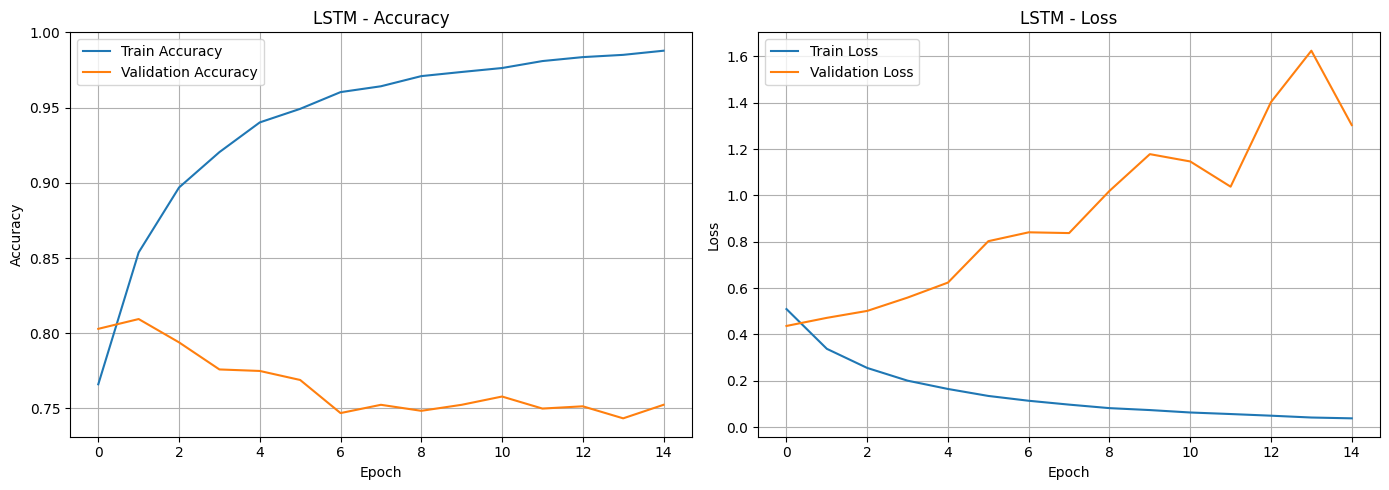

In [12]:
# Plot training & validation accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('LSTM - Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('LSTM - Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('lstm_training_plots.png', dpi=150)
plt.show()

In [13]:
# Load best model and evaluate on test set
best_model = load_model('models/LSTM.keras')

test_loss, test_accuracy = best_model.evaluate(x_test_seq, y_test_final)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8202 - loss: 0.4279

Test Loss: 0.4279
Test Accuracy: 0.8202


In [14]:
# Detailed predictions and classification report
y_pred_prob = best_model.predict(x_test_seq)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

correct = np.sum(y_pred == y_test_final)
wrong = len(y_test_final) - correct
print(f'Correct Predictions: {correct}')
print(f'Wrong Predictions: {wrong}')
print(f'Accuracy: {correct / len(y_test_final) * 100:.2f}%')
print()
print('Classification Report:')
print(classification_report(y_test_final, y_pred, target_names=['Non-Personal (0)', 'Personal (1)']))

105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
Correct Predictions: 2732
Wrong Predictions: 599
Accuracy: 82.02%

Classification Report:
                  precision    recall  f1-score   support

Non-Personal (0)       0.85      0.91      0.88      2364
    Personal (1)       0.73      0.61      0.66       967

        accuracy                           0.82      3331
       macro avg       0.79      0.76      0.77      3331
    weighted avg       0.81      0.82      0.82      3331



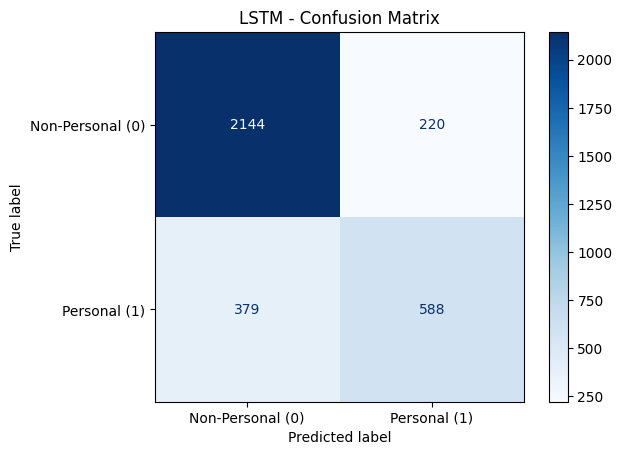

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test_final, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Personal (0)', 'Personal (1)'])
disp.plot(cmap='Blues')
plt.title('LSTM - Confusion Matrix')
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()